# 0 Libraries inladen

In [55]:
import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd

import random

env = gym.make("Blackjack-v1")

sample_size = 1000 # voor testen op 1000, voor werkelijk berekenen op 1000000

# 1 Opzetten spel

In [56]:
def blackjack(keuze_strategie): 
    obs, info = env.reset() # obs bevat de speler's som, de dealer's zichtbare kaart, en of de speler een usable ace heeft
    terminated = False # of de ronde is afgelopen
    truncated = False # of de ronde is afgebroken (bijvoorbeeld door een time limit)
    
    while not (terminated or truncated): # zolang de ronde niet is afgelopen of afgebroken
        speler_som = obs[0] # de som van de speler's kaarten
        dealer_kaarten_zichtbaar = [env.unwrapped.dealer[0]] # de zichtbare kaart van de dealer
        speler_kaarten = env.unwrapped.player # de kaarten van de speler
        
        keuze = keuze_strategie(speler_som, dealer_kaarten_zichtbaar, speler_kaarten) # de strategie bepaalt of de speler 'hit' of 'stick' kiest op basis van de huidige situatie
        
        if keuze == 'hit': 
            action = 1 # actie 1 betekent 'hit' in de Blackjack omgeving
        elif keuze == 'stick':
            action = 0 # actie 0 betekent 'stick' in de Blackjack omgeving
            
        obs, reward, terminated, truncated, info = env.step(action) # voer de gekozen actie uit in de omgeving en ontvang de nieuwe observatie, beloning, en of de ronde is afgelopen of afgebroken
        
    if reward > 0:
        resultaat = "Gewonnen" # een positieve beloning betekent dat de speler heeft gewonnen
    elif reward < 0:
        resultaat = "Verloren" # een negatieve beloning betekent dat de speler heeft verloren
    else:
        resultaat = "Gelijkspel" # een beloning van 0 betekent dat het een gelijkspel is (de speler en dealer hebben dezelfde som)
        
    return resultaat

# 2 Regels van Blackjack

# 3 Uitleg gekozen strategieën

# 4 Strategieën uitwerken en uitvoeren

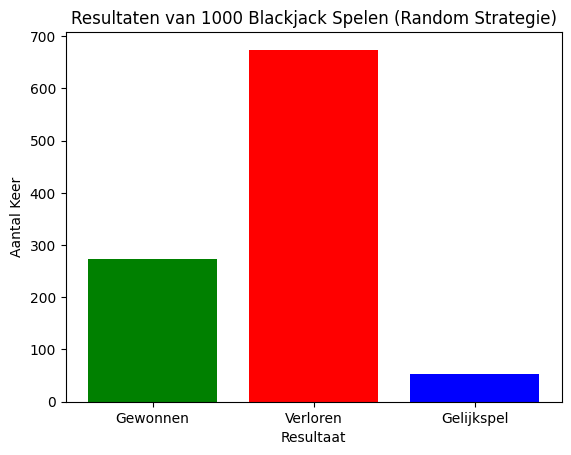

In [57]:
def baseline_strat(speler_som, dealer_kaarten_zichtbaar, speler_kaarten):
    return random.choice(['hit', 'stick']) # deze strategie kiest willekeurig tussen 'hit' en 'stick', ongeacht de situatie

baseline_results = [] 
for _ in range(sample_size):
    baseline_results.append(blackjack(baseline_strat)) # voer de blackjack functie uit met de baseline strategie en sla het resultaat op in de baseline_results lijst
    
labels = ['Gewonnen', 'Verloren', 'Gelijkspel'] 
baseline_counts = [baseline_results.count(label) for label in labels] # tel hoe vaak elk resultaat voorkomt in de baseline_results lijst en sla deze tellingen op in baseline_counts
plt.bar(labels, baseline_counts, color=['green', 'red', 'blue']) # maak een staafdiagram van de resultaten van de baseline strategie, waarbij 'Gewonnen' in groen, 'Verloren' in rood, en 'Gelijkspel' in blauw wordt weergegeven
plt.title(f'Resultaten van {sample_size} Blackjack Spelen (Random Strategie)')
plt.xlabel('Resultaat')
plt.ylabel('Aantal Keer')
plt.show()

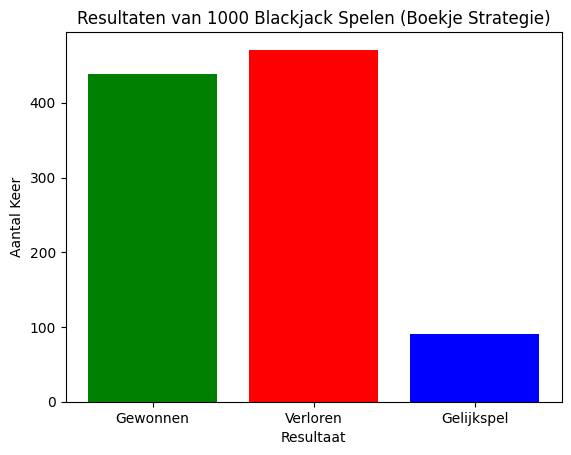

In [58]:
def strat1_boekje(speler_som, dealer_kaarten_zichtbaar, speler_kaarten):
    if speler_som == 21:  # Blackjack
        return 'stick' 
    elif 1 not in speler_kaarten: # als de speler geen Ace heeft, dan is de strategie gebaseerd op de som van de kaarten en de zichtbare kaart van de dealer
        if dealer_kaarten_zichtbaar[0] in [2, 3]: # als de dealer een 2 of 3 heeft, is het beter om te 'hit' als de speler's som 12 of minder is, omdat de kans groot is dat de dealer zal busten (boven 21 gaat)
            if speler_som <= 12:
                return 'hit'
            else:
                return 'stick'
        elif dealer_kaarten_zichtbaar[0] in [4, 5, 6]: # als de dealer een 4, 5, of 6 heeft, is het beter om te 'hit' als de speler's som 11 of minder is, omdat de kans groot is dat de dealer zal busten
            if speler_som <= 11:
                return 'hit'
            else:
                return 'stick'
        elif dealer_kaarten_zichtbaar[0] in [7, 8, 9, 10, 1]: # als de dealer een 7, 8, 9, 10, of Ace heeft, is het beter om te 'hit' als de speler's som 16 of minder is, omdat de kans groot is dat de dealer een sterke hand heeft
            if speler_som <= 16:
                return 'hit'
            else:
                return 'stick'
    else: # als de speler een Ace heeft, dan kan de Ace als 1 of 11 worden geteld, dus de strategie is gebaseerd op de som van de kaarten en de zichtbare kaart van de dealer, maar met een hogere drempel voor 'hit' omdat de speler meer flexibiliteit heeft met de Ace
        if dealer_kaarten_zichtbaar[0] in [2, 3, 4, 5, 6, 7, 8]: # als de dealer een 2, 3, 4, 5, 6, 7, of 8 heeft, is het beter om te 'hit' als de speler's som (met de Ace geteld als 11) 17 of minder is, omdat de kans groot is dat de dealer een sterke hand heeft
            if any(kaart in speler_kaarten for kaart in [2, 3, 4, 5, 6]):
                return 'hit'
            else:
                return 'stick'
        elif dealer_kaarten_zichtbaar[0] in [9, 10, 1]: # als de dealer een 9, 10, of Ace heeft, is het beter om te 'hit' als de speler's som (met de Ace geteld als 11) 18 of minder is, omdat de kans groot is dat de dealer een sterke hand heeft
            if any(kaart in speler_kaarten for kaart in [2, 3, 4, 5, 6, 7]):
                return 'hit'
            else:
                return 'stick'
        
    
strat1_results = []
for _ in range(sample_size):
    strat1_results.append(blackjack(strat1_boekje)) # voer de blackjack functie uit met de boekje strategie en sla het resultaat op in de strat1_results lijst
    
labels = ['Gewonnen', 'Verloren', 'Gelijkspel']
strat1_counts = [strat1_results.count(label) for label in labels] # tel hoe vaak elk resultaat voorkomt in de strat1_results lijst en sla deze tellingen op in strat1_counts
plt.bar(labels, strat1_counts, color=['green', 'red', 'blue']) # maak een staafdiagram van de resultaten van de boekje strategie, waarbij 'Gewonnen' in groen, 'Verloren' in rood, en 'Gelijkspel' in blauw wordt weergegeven
plt.title(f'Resultaten van {sample_size} Blackjack Spelen (Boekje Strategie)')
plt.xlabel('Resultaat')
plt.ylabel('Aantal Keer')
plt.show()

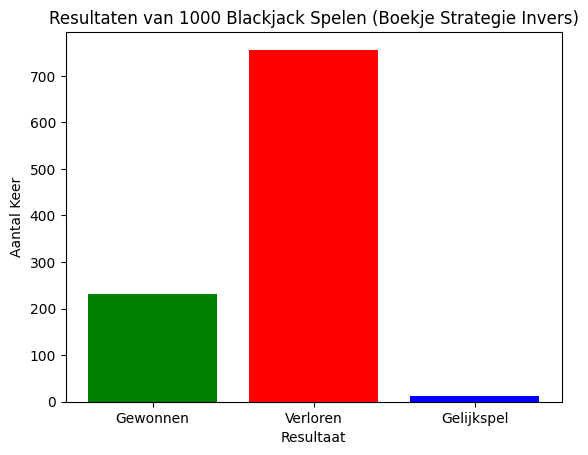

In [59]:
def strat2_boekje_invers(speler_som, dealer_kaarten_zichtbaar, speler_kaarten):
    if speler_som == 21:  # Blackjack
        return 'stick'
    elif 1 not in speler_kaarten: # als de speler geen Ace heeft, dan is de strategie gebaseerd op de som van de kaarten en de zichtbare kaart van de dealer, maar met omgekeerde beslissingen in vergelijking met de boekje strategie
        if dealer_kaarten_zichtbaar[0] in [2, 3]: # als de dealer een 2 of 3 heeft, is het beter om te 'stick' als de speler's som 12 of minder is, omdat de kans groot is dat de dealer zal busten (boven 21 gaat)
            if speler_som <= 12:
                return 'stick'
            else:
                return 'hit'
        elif dealer_kaarten_zichtbaar[0] in [4, 5, 6]: # als de dealer een 4, 5, of 6 heeft, is het beter om te 'stick' als de speler's som 11 of minder is, omdat de kans groot is dat de dealer zal busten
            if speler_som <= 11:
                return 'stick'
            else:
                return 'hit'
        elif dealer_kaarten_zichtbaar[0] in [7, 8, 9, 10, 1]: # als de dealer een 7, 8, 9, 10, of Ace heeft, is het beter om te 'stick' als de speler's som 16 of minder is, omdat de kans groot is dat de dealer een sterke hand heeft
            if speler_som <= 16:
                return 'stick'
            else:
                return 'hit'
    else: # als de speler een Ace heeft, dan kan de Ace als 1 of 11 worden geteld, dus de strategie is gebaseerd op de som van de kaarten en de zichtbare kaart van de dealer, maar met een hogere drempel voor 'stick' omdat de speler meer flexibiliteit heeft met de Ace, en met omgekeerde beslissingen in vergelijking met de boekje strategie
        if dealer_kaarten_zichtbaar[0] in [2, 3, 4, 5, 6, 7, 8]: # als de dealer een 2, 3, 4, 5, 6, 7, of 8 heeft, is het beter om te 'stick' als de speler's som (met de Ace geteld als 11) 17 of minder is, omdat de kans groot is dat de dealer een sterke hand heeft
            if any(kaart in speler_kaarten for kaart in [2, 3, 4, 5, 6]):
                return 'stick'
            else:
                return 'hit'
        elif dealer_kaarten_zichtbaar[0] in [9, 10, 1]: # als de dealer een 9, 10, of Ace heeft, is het beter om te 'stick' als de speler's som (met de Ace geteld als 11) 18 of minder is, omdat de kans groot is dat de dealer een sterke hand heeft
            if any(kaart in speler_kaarten for kaart in [2, 3, 4, 5, 6, 7]):
                return 'stick'
            else:
                return 'hit'
        
    
strat2_results = []
for _ in range(sample_size):
    strat2_results.append(blackjack(strat2_boekje_invers)) # voer de blackjack functie uit met de boekje invers strategie en sla het resultaat op in de strat2_results lijst
    
labels = ['Gewonnen', 'Verloren', 'Gelijkspel']
strat2_counts = [strat2_results.count(label) for label in labels] # tel hoe vaak elk resultaat voorkomt in de strat2_results lijst en sla deze tellingen op in strat2_counts
plt.bar(labels, strat2_counts, color=['green', 'red', 'blue']) # maak een staafdiagram van de resultaten van de boekje invers strategie, waarbij 'Gewonnen' in groen, 'Verloren' in rood, en 'Gelijkspel' in blauw wordt weergegeven
plt.title(f'Resultaten van {sample_size} Blackjack Spelen (Boekje Strategie Invers)')
plt.xlabel('Resultaat')
plt.ylabel('Aantal Keer')
plt.show()

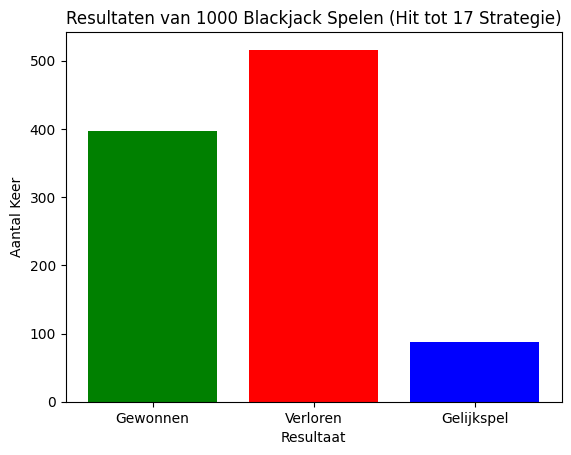

In [60]:
def strat3_hit_17(speler_som, dealer_kaarten_zichtbaar, speler_kaarten):
    if speler_som == 21:  # Blackjack
        return 'stick'
    elif speler_som <= 17: # deze strategie kiest altijd 'hit' als de som van de speler's kaarten 17 of minder is, ongeacht de zichtbare kaart van de dealer of de specifieke kaarten van de speler, en kiest 'stick' als de som 18 of meer is
        return 'hit'
    else:
        return 'stick'
        
    
strat3_results = []
for _ in range(sample_size):
    strat3_results.append(blackjack(strat3_hit_17)) # voer de blackjack functie uit met de hit tot 17 strategie en sla het resultaat op in de strat3_results lijst
    
labels = ['Gewonnen', 'Verloren', 'Gelijkspel']
strat3_counts = [strat3_results.count(label) for label in labels] # tel hoe vaak elk resultaat voorkomt in de strat3_results lijst en sla deze tellingen op in strat3_counts
plt.bar(labels, strat3_counts, color=['green', 'red', 'blue']) # maak een staafdiagram van de resultaten van de hit tot 17 strategie, waarbij 'Gewonnen' in groen, 'Verloren' in rood, en 'Gelijkspel' in blauw wordt weergegeven
plt.title(f'Resultaten van {sample_size} Blackjack Spelen (Hit tot 17 Strategie)')
plt.xlabel('Resultaat')
plt.ylabel('Aantal Keer')
plt.show()

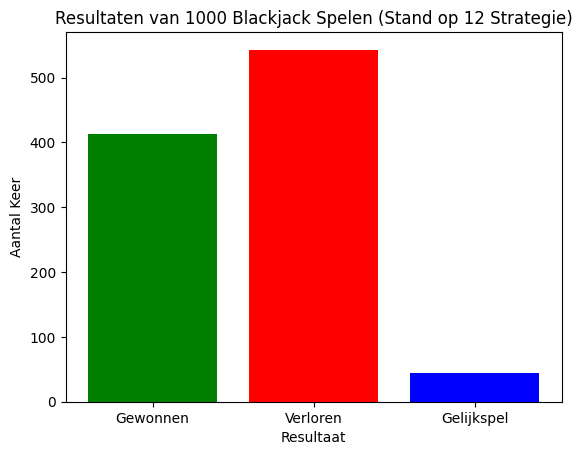

In [61]:
def strat4_stand_12(speler_som, dealer_kaarten_zichtbaar, speler_kaarten):
    if speler_som == 21:  # Blackjack
        return 'stick'
    elif speler_som >= 12: # deze strategie kiest altijd 'stick' als de som van de speler's kaarten 12 of meer is, ongeacht de zichtbare kaart van de dealer of de specifieke kaarten van de speler, en kiest 'hit' als de som 11 of minder is
        return 'stick'
    else:
        return 'hit'
        
    
strat4_results = []
for _ in range(sample_size):
    strat4_results.append(blackjack(strat4_stand_12)) # voer de blackjack functie uit met de stand op 12 strategie en sla het resultaat op in de strat4_results lijst
    
labels = ['Gewonnen', 'Verloren', 'Gelijkspel']
strat4_counts = [strat4_results.count(label) for label in labels] # tel hoe vaak elk resultaat voorkomt in de strat4_results lijst en sla deze tellingen op in strat4_counts
plt.bar(labels, strat4_counts, color=['green', 'red', 'blue']) # maak een staafdiagram van de resultaten van de stand op 12 strategie, waarbij 'Gewonnen' in groen, 'Verloren' in rood, en 'Gelijkspel' in blauw wordt weergegeven
plt.title(f'Resultaten van {sample_size} Blackjack Spelen (Stand op 12 Strategie)')
plt.xlabel('Resultaat')
plt.ylabel('Aantal Keer')
plt.show()

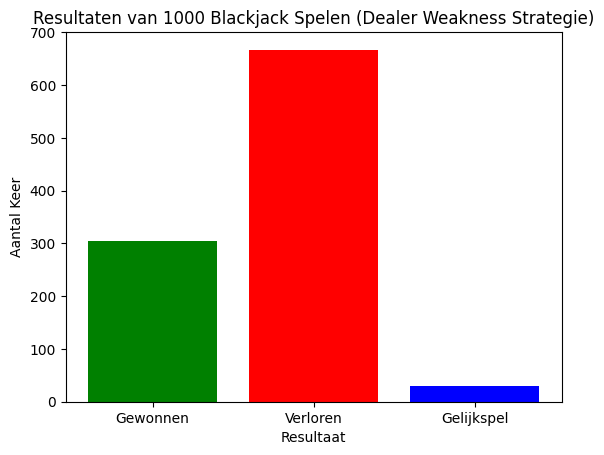

In [62]:
def strat5_dealer_weakness(speler_som, dealer_kaarten_zichtbaar, speler_kaarten):
    if speler_som == 21:  # Blackjack
        return 'stick'
    elif dealer_kaarten_zichtbaar[0] in [2, 3, 4, 5, 6]: # deze strategie kiest 'hit' als de dealer een zwakke kaart heeft (2, 3, 4, 5, of 6)
        return 'stick'
    elif dealer_kaarten_zichtbaar[0] in [7, 8, 9, 10, 1]: # deze strategie kiest 'hit' als de dealer een sterke kaart heeft (7, 8, 9, 10, of Ace)
        if speler_som <= 21:
            return 'hit'
        else:
            return 'stick'
        
    
strat5_results = []
for _ in range(sample_size):
    strat5_results.append(blackjack(strat5_dealer_weakness)) # voer de blackjack functie uit met de dealer weakness strategie en sla het resultaat op in de strat5_results lijst
    
labels = ['Gewonnen', 'Verloren', 'Gelijkspel']
strat5_counts = [strat5_results.count(label) for label in labels] # tel hoe vaak elk resultaat voorkomt in de strat5_results lijst en sla deze tellingen op in strat5_counts
plt.bar(labels, strat5_counts, color=['green', 'red', 'blue']) # maak een staafdiagram van de resultaten van de dealer weakness strategie, waarbij 'Gewonnen' in groen, 'Verloren' in rood, en 'Gelijkspel' in blauw wordt weergegeven
plt.title(f'Resultaten van {sample_size} Blackjack Spelen (Dealer Weakness Strategie)')
plt.xlabel('Resultaat')
plt.ylabel('Aantal Keer')
plt.show()

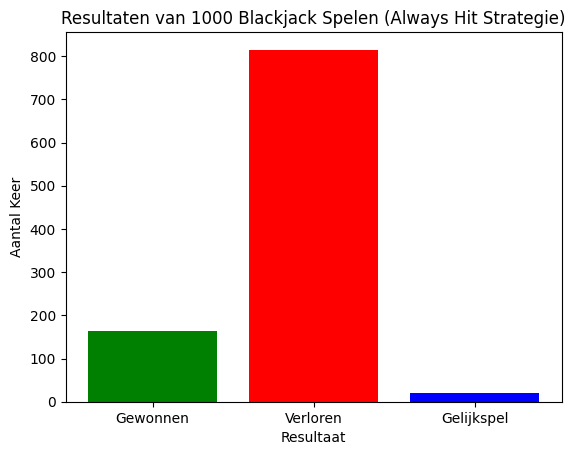

In [63]:
def strat6_always_hit(speler_som, dealer_kaarten_zichtbaar, speler_kaarten):
    if speler_som != 21:  # deze strategie kiest altijd 'hit' als de som van de speler's kaarten niet 21 is, ongeacht de zichtbare kaart van de dealer of de specifieke kaarten van de speler, en kiest 'stick' alleen als de speler al een Blackjack heeft
        return 'hit'
    else:
        return 'stick'
        
    
strat6_results = []
for _ in range(sample_size):
    strat6_results.append(blackjack(strat6_always_hit)) # voer de blackjack functie uit met de always hit strategie en sla het resultaat op in de strat6_results lijst
    
labels = ['Gewonnen', 'Verloren', 'Gelijkspel']
strat6_counts = [strat6_results.count(label) for label in labels] # tel hoe vaak elk resultaat voorkomt in de strat6_results lijst en sla deze tellingen op in strat6_counts
plt.bar(labels, strat6_counts, color=['green', 'red', 'blue']) # maak een staafdiagram van de resultaten van de always hit strategie, waarbij 'Gewonnen' in groen, 'Verloren' in rood, en 'Gelijkspel' in blauw wordt weergegeven
plt.title(f'Resultaten van {sample_size} Blackjack Spelen (Always Hit Strategie)')
plt.xlabel('Resultaat')
plt.ylabel('Aantal Keer')
plt.show()

# 5 Strategieën vergelijken

In [68]:
df = pd.DataFrame({
    'Strategie': ['Random (Baseline)', 'Boekje', 'Boekje Invers', 'Hit tot 17', 'Stand vanaf 12', 'Dealer Weakness', 'Always Hit'],
    'Gewonnen': [baseline_results.count('Gewonnen'), strat1_results.count('Gewonnen'), strat2_results.count('Gewonnen'), strat3_results.count('Gewonnen'), strat4_results.count('Gewonnen'), strat5_results.count('Gewonnen'), strat6_results.count('Gewonnen')],
    'Verloren': [baseline_results.count('Verloren'), strat1_results.count('Verloren'), strat2_results.count('Verloren'), strat3_results.count('Verloren'), strat4_results.count('Verloren'), strat5_results.count('Verloren'), strat6_results.count('Verloren')],
    'Gelijkspel': [baseline_results.count('Gelijkspel'), strat1_results.count('Gelijkspel'), strat2_results.count('Gelijkspel'), strat3_results.count('Gelijkspel'), strat4_results.count('Gelijkspel'), strat5_results.count('Gelijkspel'), strat6_results.count('Gelijkspel')],
    'Gewonnen (%)': [round(baseline_results.count('Gewonnen') / sample_size * 100, 1), round(strat1_results.count('Gewonnen') / sample_size * 100, 1), round(strat2_results.count('Gewonnen') / sample_size * 100, 1), round(strat3_results.count('Gewonnen') / sample_size * 100, 1), round(strat4_results.count('Gewonnen') / sample_size * 100, 1), round(strat5_results.count('Gewonnen') / sample_size * 100, 1), round(strat6_results.count('Gewonnen') / sample_size * 100, 1)],
    'Verloren (%)': [round(baseline_results.count('Verloren') / sample_size * 100, 1), round(strat1_results.count('Verloren') / sample_size * 100, 1), round(strat2_results.count('Verloren') / sample_size * 100, 1), round(strat3_results.count('Verloren') / sample_size * 100, 1), round(strat4_results.count('Verloren') / sample_size * 100, 1), round(strat5_results.count('Verloren') / sample_size * 100, 1), round(strat6_results.count('Verloren') / sample_size * 100, 1)],
})

In [69]:
df

,Strategie,Gewonnen,Verloren,Gelijkspel,Gewonnen (%),Verloren (%)
0,Random (Baseline),273,674,53,27.3,67.4
1,Boekje,439,471,90,43.9,47.1
2,Boekje Invers,232,756,12,23.2,75.6
3,Hit tot 17,397,516,87,39.7,51.6
4,Stand vanaf 12,413,543,44,41.3,54.3
5,Dealer Weakness,304,667,29,30.4,66.7
6,Always Hit,164,815,21,16.4,81.5
